# Klasifikasi Pelanggan yang akan Membeli Komputer Menggunakan Metode ID3

## Import Library

In [ ]:
# Library untuk pengolahan data
import pandas as pd
import numpy as np
import math

# Library untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Library untuk encoder
!pip install --upgrade category_encoders
import category_encoders as ce

# Library unruk Decision Tree
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
import sklearn.metrics as metrics
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, classification_report, accuracy_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 1.9 MB/s eta 0:00:00


## Read Data

In [ ]:
# Read Data

data = pd.read_excel('/content/DataBuysComputer.xlsx')

In [ ]:
data

,id,Age,Income,Student,Credit_rating,Buys Computer
0,1,(<=30),High,no,fair,no
1,2,(<=30),High,no,excelent,no
2,3,31..40,High,no,fair,yes
3,4,(>40),Medium,no,fair,yes
4,5,(>40),Low,yes,fair,yes
5,6,(>40),Low,yes,excelent,no
6,7,31..40,Low,yes,excelent,yes
7,8,(<=30),Medium,no,fair,no
8,9,(<=30),Low,yes,fair,yes
9,10,(>40),Medium,yes,fair,yes


In [ ]:
# Menampilkan semua baris data dan menghapus kolom pertama('id')

data = data.iloc[:, 1:]

In [ ]:
# Untuk data 'no' dan 'yes' di kolom 'Buys Computer' dibuat warna berbeda
# Tabel juga diberi style

def highlight(cell_value):
  color_1 = 'background-color: pink;'
  color_2 = 'background-color: lightgreen;'

  if cell_value == 'yes':
    return color_1
  elif cell_value == 'no':
    return color_2
data.style.applymap(highlight, subset=['Buys Computer'])\
  .set_properties(subset=data.columns, **{'width': '100px'})\
  .set_table_styles([{'selector': 'th', 'props': [('background-color', 'lightgray'),
                                                ('border', '1px solid gray'),
                                                ('font-weight', 'bold')]},
  {'selector': 'td', 'props': [('border', '1px solid black'),
                                                 ('background_color', 'white')]}])

<ipython-input-5-d9a32a0c8df3>:12: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  data.style.applymap(highlight, subset=['Buys Computer'])\


,Age,Income,Student,Credit_rating,Buys Computer
0,(<=30),High,no,fair,no
1,(<=30),High,no,excelent,no
2,31..40,High,no,fair,yes
3,(>40),Medium,no,fair,yes
4,(>40),Low,yes,fair,yes
5,(>40),Low,yes,excelent,no
6,31..40,Low,yes,excelent,yes
7,(<=30),Medium,no,fair,no
8,(<=30),Low,yes,fair,yes
9,(>40),Medium,yes,fair,yes


## Mencari Nilai Entropy dan Information Gain

In [ ]:
# Rumus Mencari Nilai Entropy

def find_entropy(data):
  entropy = 0
  for i in range(data.nunique()):
    x = data.value_counts().iloc[i]/data.shape[0]
    entropy += (- x * math.log(x,2))
  return round(entropy, 4)

In [ ]:
# Rumus Mencari Nilai Information Gain

def information_gain(data, data_):
  info = 0
  for i in range(data_.nunique()):
    df = data[data_ == data_.unique()[i]]
    w_avg = df.shape[0]/data.shape[0]
    entropy = find_entropy(df['Buys Computer'])
    x = w_avg * entropy
    info += x
  ig = find_entropy(data['Buys Computer']) - info
  return round(ig, 4)

In [ ]:
# Rumus Mencari Nilai Entropy dan Information Gain

def entropy_and_infogain(datax, feature):
  for i in range(data[feature].nunique()):
    df = datax[datax[feature]==data[feature].unique()[i]]
    if df.shape[0] < 1:
      continue
      display(df[[feature, 'yes']].style.applymap(highlight)\
              .set_properties(subset=[feature, 'yes'], **{'width': '100px'})\
              .set_table_styles([{'selector': 'th', 'props': [('background_color', 'lightgray'),
                                                              ('border', '1px solid gray'),
                                                              ('font-weight', 'bold')]},
                                 {'selector': 'td', 'props': [('border', '1px solid gray')]},
                                 {'selector': 'tr:hover', props: [('background-color', 'lightblue'),
                                                                  ('border', '1px solid black')]}]))
    print(f'Entropy of {feature} - {data[feature].unique()[i]} = {find_entropy(df["Buys Computer"])}')
  print(f'Information Gain of {feature} = {information_gain(datax, datax[feature])}\n')

## Mencari Nilai Entropy Total

In [ ]:
# Mencari Entropy Total

print(f'Entropy of the entire dataset: {find_entropy(data["Buys Computer"])}')

Entropy of the entire dataset: 0.9403


In [ ]:
# Hasil Entropy dan Information Gain 'Age'
entropy_and_infogain(data, 'Age')

# Hasil Entropy dan Information Gain 'Income'
entropy_and_infogain(data, 'Income')

# Hasil Entropy dan Information Gain 'Student'
entropy_and_infogain(data, 'Student')

# Hasil Entropy dan Information Gain 'Credit_rating'
entropy_and_infogain(data, 'Credit_rating')

Entropy of Age - (<=30) = 0.971
Entropy of Age - 31..40 = 0.0
Entropy of Age - (>40) = 0.971
Information Gain of Age = 0.2467

Entropy of Income - High = 1.0
Entropy of Income - Medium = 0.9183
Entropy of Income - Low = 0.8113
Information Gain of Income = 0.0292

Entropy of Student - no = 0.9852
Entropy of Student - yes = 0.5917
Information Gain of Student = 0.1519

Entropy of Credit_rating - fair = 0.8113
Entropy of Credit_rating - excelent = 1.0
Information Gain of Credit_rating = 0.0481



In [ ]:
# Melihat Informasi dari atribut 'Age' 30..40 yang merupakan node 1.2

_30sampai40 = data[data['Age'] == '31..40']
_30sampai40.style.applymap(highlight, subset=['Buys Computer'])\
  .set_properties(subset=data.columns, **{'width': '100px'})\
  .set_table_styles([{'selector': 'th', 'props': [('background-color', 'lightgray'),
                                                ('border', '1px solid gray'),
                                                ('font-weight', 'bold')]},
  {'selector': 'td', 'props': [('border', '1px solid black'),
                                                 ('background_color', 'white')]}])

<ipython-input-11-e7585184c503>:4: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  _30sampai40.style.applymap(highlight, subset=['Buys Computer'])\


,Age,Income,Student,Credit_rating,Buys Computer
2,31..40,High,no,fair,yes
6,31..40,Low,yes,excelent,yes
11,31..40,Medium,no,excelent,yes
12,31..40,High,yes,fair,yes


## Mencari Nilai Entropy dengan Nilai Gain paling besar untuk node 1.1

In [ ]:
# Mencari Entropy & Information Gain 'Age' (<=30)

kurang30 = data[data['Age'] == '(<=30)']
kurang30.style.applymap(highlight, subset=['Buys Computer'])\
  .set_properties(subset=data.columns, **{'width': '100px'})\
  .set_table_styles([{'selector': 'th', 'props': [('background-color', 'lightgray'),
                                                ('border', '1px solid gray'),
                                                ('font-weight', 'bold')]},
  {'selector': 'td', 'props': [('border', '1px solid black'),
                                                 ('background_color', 'white')]}])

<ipython-input-12-4f8e2992f749>:4: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  kurang30.style.applymap(highlight, subset=['Buys Computer'])\


,Age,Income,Student,Credit_rating,Buys Computer
0,(<=30),High,no,fair,no
1,(<=30),High,no,excelent,no
7,(<=30),Medium,no,fair,no
8,(<=30),Low,yes,fair,yes
10,(<=30),Medium,yes,excelent,yes


In [ ]:
# Mencari Entropy total 'Age' (<=30)
print(f'Entropy of the entire dataset: {find_entropy(kurang30["Buys Computer"])}\n')

# Hasil Entropy & Information Gain 'Age' (<=30) 'Income'
entropy_and_infogain(kurang30, 'Income')

# Hasil Entropy & Information Gain 'Age' (<=30) & 'Student'
entropy_and_infogain(kurang30, 'Student')

# Hasil Entropy & Information Gain 'Age' (<=30) & 'Credit_rating'
entropy_and_infogain(kurang30, 'Credit_rating')

Entropy of the entire dataset: 0.971

Entropy of Income - High = 0.0
Entropy of Income - Medium = 1.0
Entropy of Income - Low = 0.0
Information Gain of Income = 0.571

Entropy of Student - no = 0.0
Entropy of Student - yes = 0.0
Information Gain of Student = 0.971

Entropy of Credit_rating - fair = 0.9183
Entropy of Credit_rating - excelent = 1.0
Information Gain of Credit_rating = 0.02



## Mencari Nilai Entropy dengan Nilai Gain paling besar untuk Node 1.3

In [ ]:
# Mencari Entropy & Information Gain 'Age' (>40)

lebih40 = data[data['Age'] == '(>40)']
lebih40.style.applymap(highlight, subset=['Buys Computer'])\
  .set_properties(subset=data.columns, **{'width': '100px'})\
  .set_table_styles([{'selector': 'th', 'props': [('background-color', 'lightgray'),
                                                ('border', '1px solid gray'),
                                                ('font-weight', 'bold')]},
  {'selector': 'td', 'props': [('border', '1px solid black'),
                                                 ('background_color', 'white')]}])

<ipython-input-14-2e69d6c87143>:4: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  lebih40.style.applymap(highlight, subset=['Buys Computer'])\


,Age,Income,Student,Credit_rating,Buys Computer
3,(>40),Medium,no,fair,yes
4,(>40),Low,yes,fair,yes
5,(>40),Low,yes,excelent,no
9,(>40),Medium,yes,fair,yes
13,(>40),Medium,no,excelent,no


In [ ]:
# Mencari Entropy total 'Age' (>40)
print(f'Entropy of the entire dataset: {find_entropy(lebih40["Buys Computer"])}\n')

# hasil Entropy & Information Gain 'Age' (>40) & 'Income'
entropy_and_infogain(lebih40, 'Income')

# hasil Entropy & Information Gain 'Age' (>40) & 'Student'
entropy_and_infogain(lebih40, 'Student')

# hasil Entropy & Information Gain 'Age' (>40) 'Credit_rating'
entropy_and_infogain(lebih40, 'Credit_rating')

Entropy of the entire dataset: 0.971

Entropy of Income - Medium = 0.9183
Entropy of Income - Low = 1.0
Information Gain of Income = 0.02

Entropy of Student - no = 1.0
Entropy of Student - yes = 0.9183
Information Gain of Student = 0.02

Entropy of Credit_rating - fair = 0.0
Entropy of Credit_rating - excelent = 0.0
Information Gain of Credit_rating = 0.971



## Build Model

In [ ]:
# Independent Dependent Variable

x = data.drop(['Buys Computer'], axis=1) # x sebagai variabel untuk menampung atribut feature
y = data['Buys Computer'] # y sebagai variabel untuk menampung atribut class/label

In [ ]:
# Encode data independent karena masih bertipe kategorial

encoder = ce.OrdinalEncoder(cols=['Age', 'Income', 'Student', 'Credit_rating'])
x_encode = encoder.fit_transform(x)
x_encode

,Age,Income,Student,Credit_rating
0,1,1,1,1
1,1,1,1,2
2,2,1,1,1
3,3,2,1,1
4,3,3,2,1
5,3,3,2,2
6,2,3,2,2
7,1,2,1,1
8,1,3,2,1
9,3,2,2,1


In [ ]:
y

,Buys Computer
0,no
1,no
2,yes
3,yes
4,yes
5,no
6,yes
7,no
8,yes
9,yes


In [ ]:
# Split Train Test

from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_encode, y, test_size=0.2, random_state=1) # 20% data test

In [ ]:
#Create Model

model = DecisionTreeClassifier()
model.fit(x_encode, y)

DecisionTreeClassifier()

In [ ]:
# Prediksi Data Test

y_predict = model.predict(x_test)
y_predict

array(['yes', 'no', 'yes'], dtype=object)

Evaluasi Model

Akurasi Test:  1.0


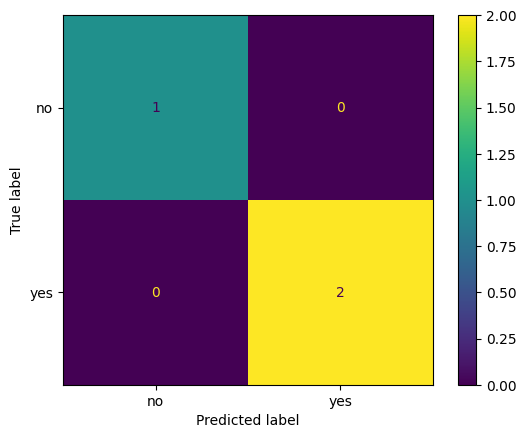

In [ ]:
#Akurasi Test

print("Akurasi Test: ", metrics.accuracy_score(y_test, y_predict))
ConfusionMatrixDisplay.from_predictions(y_test, y_predict)

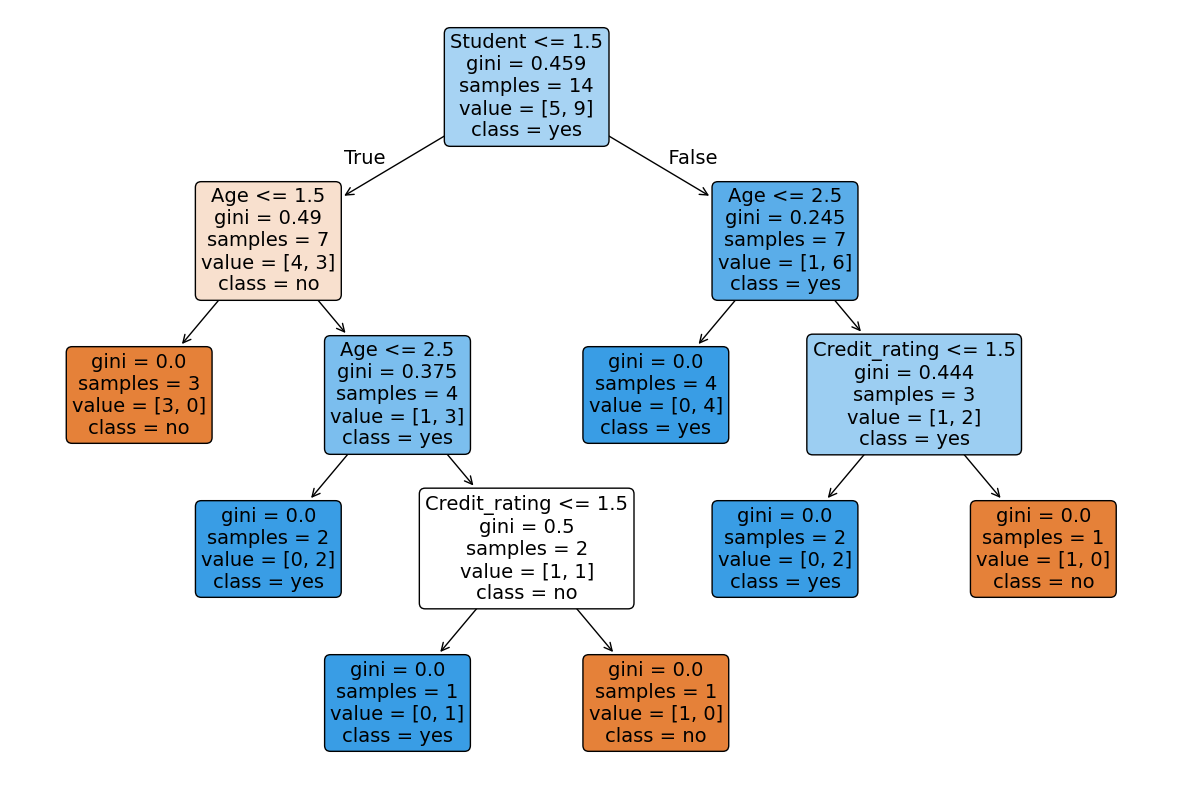

In [ ]:
# Visualisasi Decision Tree

fn = ['Age', 'Income', 'Student', 'Credit_rating']
cn = ['no', 'yes']
fig = plt.figure(figsize=(15, 10))
pict_tree = plot_tree(model, feature_names=fn, class_names=cn, filled=True, rounded=True, fontsize=14)

In [ ]:
# Save Picture Decision Tree
fig.savefig('Picture ID3 Buys Computer.jpg', format='jpg', bbox_inches='tight')

In [ ]:
# Cek Hasil Encoding

print(encoder.category_mapping)

[{'col': 'Age', 'mapping': (<=30)    1
31..40    2
(>40)     3
NaN      -2
dtype: int64, 'data_type': dtype('O')}, {'col': 'Income', 'mapping': High      1
Medium    2
Low       3
NaN      -2
dtype: int64, 'data_type': dtype('O')}, {'col': 'Student', 'mapping': no     1
yes    2
NaN   -2
dtype: int64, 'data_type': dtype('O')}, {'col': 'Credit_rating', 'mapping': fair        1
excelent    2
NaN        -2
dtype: int64, 'data_type': dtype('O')}]


In [ ]:
# Input Test model
# Jika age <=30, income= medium, student=yes, credit_rating=fair maka?

input_test = pd.DataFrame([[1, 2, 2, 1]], columns = ['Age', 'Income', 'Student', 'Credit_rating'])
input_test

,Age,Income,Student,Credit_rating
0,1,2,2,1


In [ ]:
# Test model

predict = model.predict(input_test)
print("Hasil Prediksi: ",predict)

Hasil Prediksi:  ['yes']
